In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
train_df = pd.read_pickle(r'D:\Uni\Year_3_sem_2\XAI\Project\phase_2\Final_processed_data\train_final.pkl')
test_df = pd.read_pickle(r'D:\Uni\Year_3_sem_2\XAI\Project\phase_2\Final_processed_data\test_final.pkl')
print("Loaded preprocessed data from pickle files")

Loaded preprocessed data from pickle files


In [3]:
df = train_df.copy()
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.shape[1]} features + 1 target")

Dataset shape: (59844, 206)
Columns: 206 features + 1 target


In [5]:
print(f"Total hourly records: {len(df)}")
print(f"Target distribution:\n{df['SepsisLabel'].value_counts(normalize=True)}")
print(f"Features: {df.shape[1]}")
print(f"Missing values per feature:\n{df.isnull().mean().sort_values(ascending=False).head(10)}")

Total hourly records: 59844
Target distribution:
SepsisLabel
0    0.5
1    0.5
Name: proportion, dtype: float64
Features: 206
Missing values per feature:
HR_mean       0.0
HR_max        0.0
HR_min        0.0
HR_last       0.0
O2Sat_mean    0.0
O2Sat_max     0.0
O2Sat_min     0.0
O2Sat_last    0.0
Temp_mean     0.0
Temp_max      0.0
dtype: float64


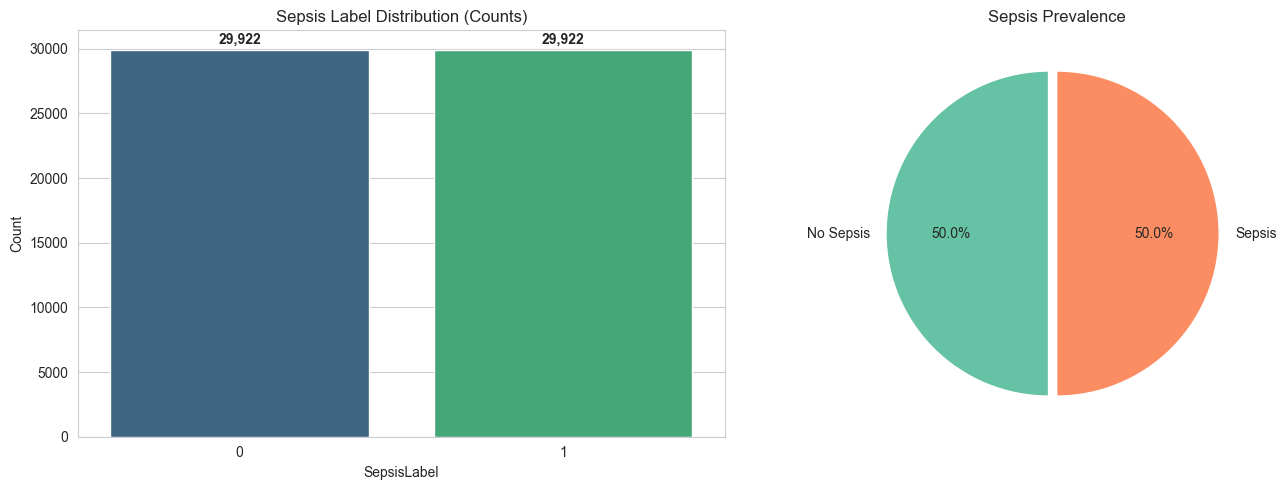


 Target Statistics:
  • Total samples: 59,844
  • Sepsis cases: 29,922 (50.00%)
  • Non-sepsis: 29,922 (50.00%)
  • Imbalance ratio: 1.0:1


In [6]:
# Target distribution
target_counts = df['SepsisLabel'].value_counts()
target_pct = df['SepsisLabel'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Sepsis Label Distribution (Counts)')
axes[0].set_xlabel('SepsisLabel')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_pct.values, labels=['No Sepsis', 'Sepsis'], autopct='%1.1f%%', 
            colors=['#66c2a5', '#fc8d62'], startangle=90, explode=(0.05, 0))
axes[1].set_title('Sepsis Prevalence')

plt.tight_layout()
plt.show()

print(f"\n Target Statistics:")
print(f"  • Total samples: {len(df):,}")
print(f"  • Sepsis cases: {target_counts.get(1, 0):,} ({target_pct.get(1, 0):.2f}%)")
print(f"  • Non-sepsis: {target_counts.get(0, 0):,} ({target_pct.get(0, 0):.2f}%)")
print(f"  • Imbalance ratio: {target_counts.get(0, 0)/max(1, target_counts.get(1, 0)):.1f}:1")

In [8]:
# 3. Feature Overview & Missing Data

# Separate feature types
numeric_cols = [c for c in df.columns if c not in ['Patient_ID', 'SepsisLabel'] and df[c].dtype in ['float64', 'float32', 'int64']]
missing_cols = [c for c in numeric_cols if 'missing' in c]
clinical_cols = [c for c in numeric_cols if c not in missing_cols]

print(f"\n Feature Breakdown:")
print(f"  • Total features: {len(numeric_cols)}")
print(f"  • Clinical features: {len(clinical_cols)}")
print(f"  • Missing-indicator features: {len(missing_cols)}")

# Missing data summary (post-imputation, should be minimal)
missing_summary = df[clinical_cols].isnull().sum()
if missing_summary.sum() > 0:
    print(f"\n Remaining missing values: {missing_summary.sum()}")
    print(missing_summary[missing_summary > 0])
else:
    print(f"\n No missing values in clinical features (imputation successful)")


 Feature Breakdown:
  • Total features: 205
  • Clinical features: 164
  • Missing-indicator features: 41

 No missing values in clinical features (imputation successful)


In [11]:
summary = df.describe().T
summary['skewness'] = df.select_dtypes(include=np.number).skew()
summary['kurtosis'] = df.select_dtypes(include=np.number).kurtosis()
summary.style \
    .background_gradient(cmap='RdYlGn', subset=['skewness']) \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .format(precision=3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
HR_mean,59844.000,0.140,0.985,-3.658,-0.545,0.095,0.775,6.214,0.288,0.185
HR_max,59844.000,0.167,0.991,-3.374,-0.522,0.124,0.826,6.271,0.286,0.237
HR_min,59844.000,0.102,1.016,-3.576,-0.623,0.026,0.746,6.112,0.493,0.582
HR_last,59844.000,0.175,0.991,-3.803,-0.521,0.135,0.819,6.520,0.328,0.260
O2Sat_mean,59844.000,0.040,0.914,-32.021,-0.395,0.145,0.629,1.305,-5.183,92.605
O2Sat_max,59844.000,0.028,0.868,-60.940,0.143,0.364,0.364,0.364,-14.711,724.338
O2Sat_min,59844.000,-0.032,0.956,-10.685,-0.276,0.161,0.459,1.202,-4.211,29.761
O2Sat_last,59844.000,0.049,0.851,-19.090,-0.219,0.136,0.585,0.837,-7.056,104.446
Temp_mean,59844.000,0.148,1.098,-11.837,-0.536,0.117,0.853,5.507,-0.272,2.516
Temp_max,59844.000,0.228,1.124,-9.612,-0.580,0.163,1.002,17.236,0.168,1.257


In [12]:
# Grouped Statistics by Target
# This shows which features differ between sepsis and non-sepsis groups
grouped_stats = df.groupby('SepsisLabel').agg(['mean', 'median', 'std']).T
print('Statistical comparison: Sepsis (1) vs Non-Sepsis (0)')
grouped_stats.head(20)

Statistical comparison: Sepsis (1) vs Non-Sepsis (0)


SepsisLabel               0         1
HR_mean    mean   -0.029110  0.308817
           median -0.073993  0.264239
           std     0.984700  0.956003
HR_max     mean   -0.034993  0.368752
           median -0.107458  0.359197
           std     0.983265  0.957284
HR_min     mean   -0.020446  0.223697
           median -0.118349  0.117998
           std     0.979292  1.036845
HR_last    mean   -0.034853  0.385733
           median -0.103203  0.345306
           std     0.980950  0.956475
O2Sat_mean mean   -0.003773  0.084441
           median  0.106834  0.181540
           std     0.998044  0.818673
O2Sat_max  mean   -0.003473  0.059205
           median  0.364130  0.364130
           std     1.009174  0.697755
O2Sat_min  mean    0.011752 -0.076433
           median  0.161477  0.076674

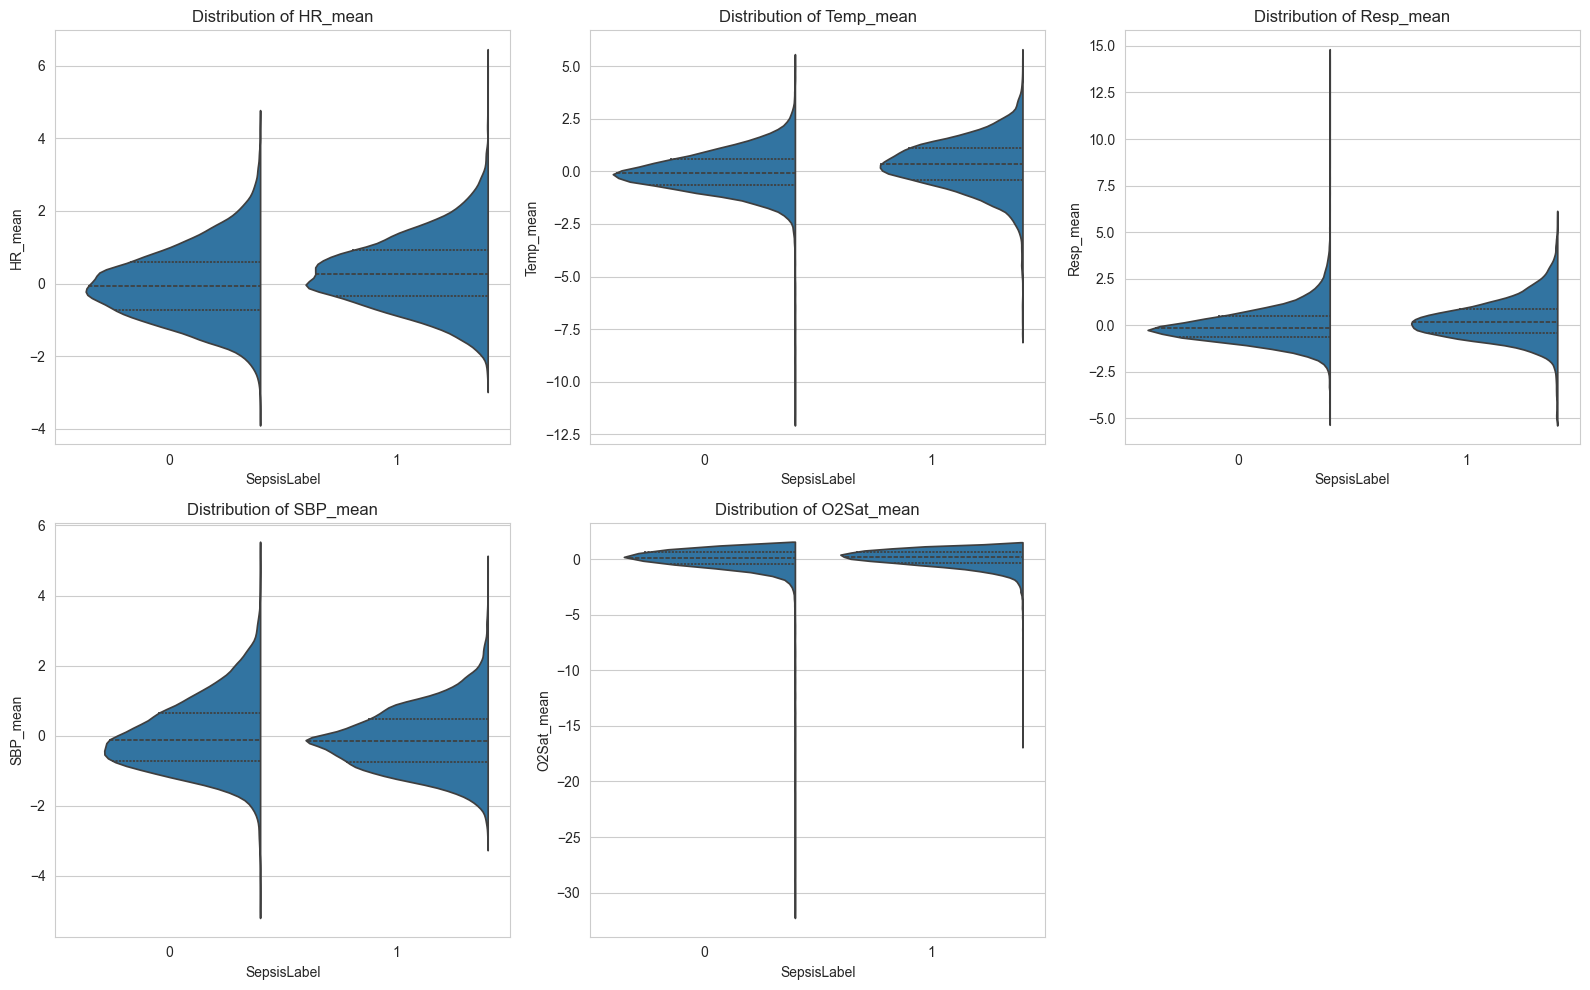

In [19]:
# Focus on the 'mean' of core vital signs
vitals_mean = ['HR_mean', 'Temp_mean', 'Resp_mean', 'SBP_mean', 'O2Sat_mean']

plt.figure(figsize=(16, 10))
for i, feature in enumerate(vitals_mean):
    plt.subplot(2, 3, i+1)
    sns.violinplot(x='SepsisLabel', y=feature, data=df, split=True, inner="quart")
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

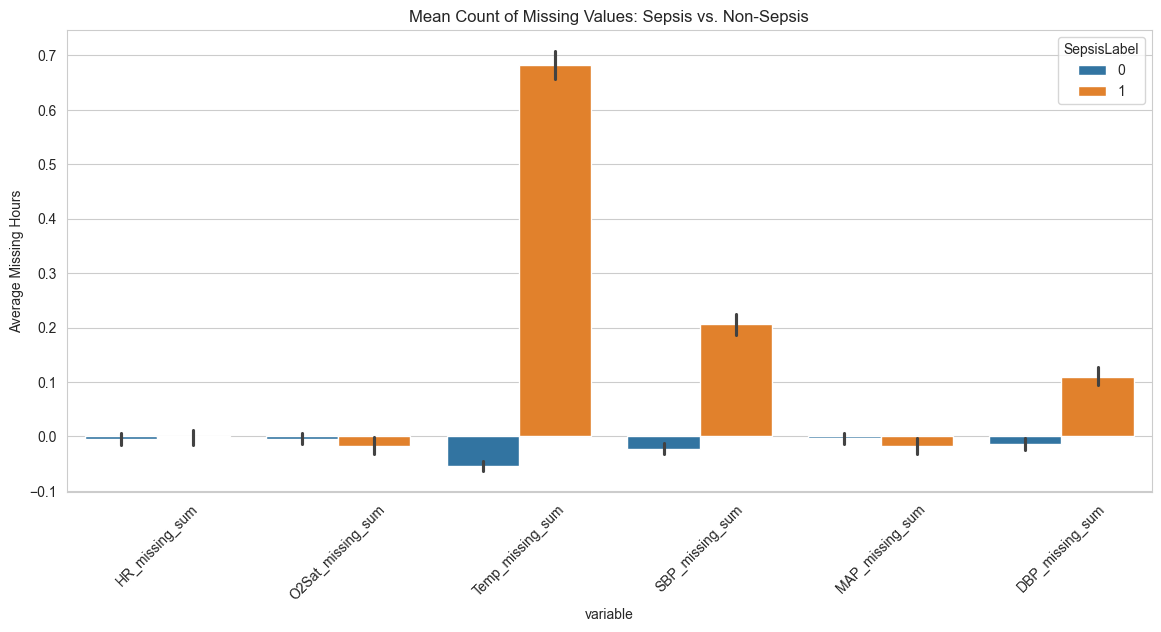

In [20]:
# Select a few 'missing_sum' features to visualize
missing_cols = [col for col in df.columns if 'missing_sum' in col][:6]

plt.figure(figsize=(14, 6))
df_melted = df.melt(id_vars='SepsisLabel', value_vars=missing_cols)
sns.barplot(x='variable', y='value', hue='SepsisLabel', data=df_melted)
plt.xticks(rotation=45)
plt.title('Mean Count of Missing Values: Sepsis vs. Non-Sepsis')
plt.ylabel('Average Missing Hours')
plt.show()

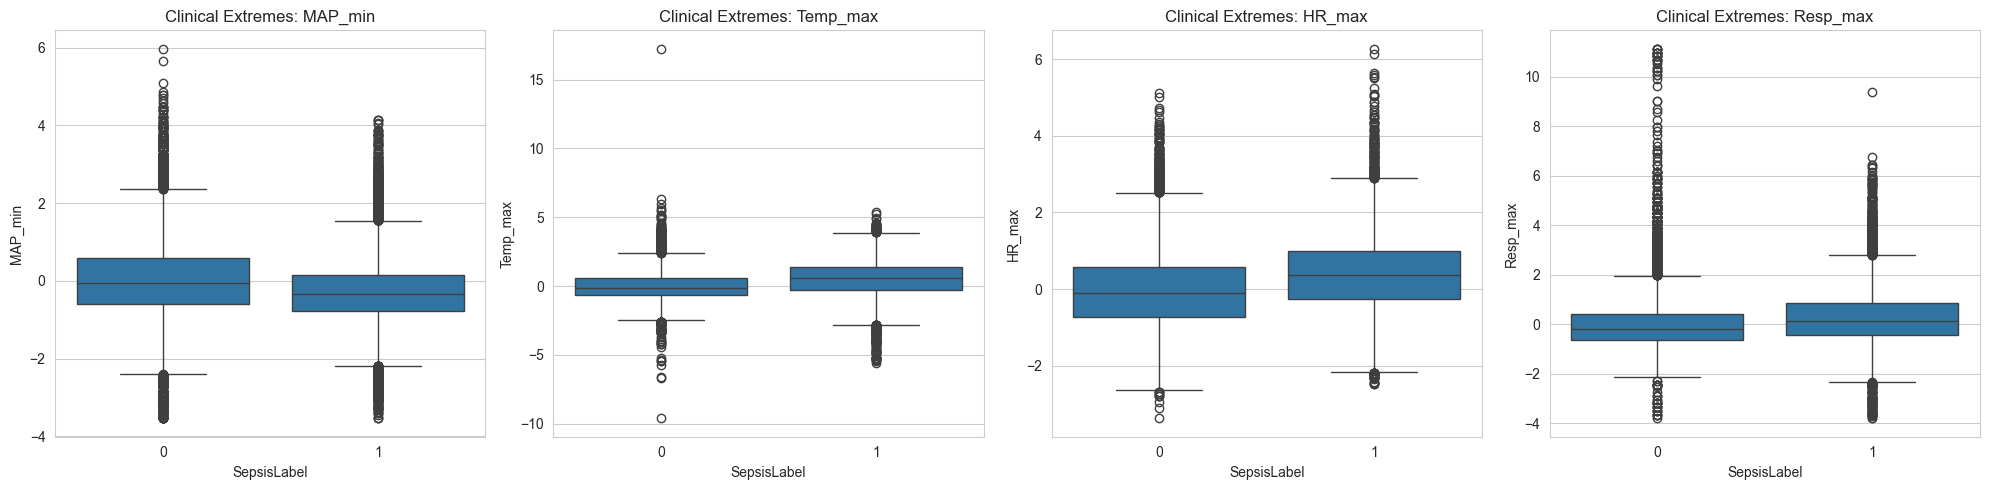

In [21]:
extreme_features = ['MAP_min', 'Temp_max', 'HR_max', 'Resp_max']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, feat in enumerate(extreme_features):
    sns.boxplot(x='SepsisLabel', y=feat, data=df, ax=axes[i])
    axes[i].set_title(f'Clinical Extremes: {feat}')

plt.tight_layout()
plt.show()

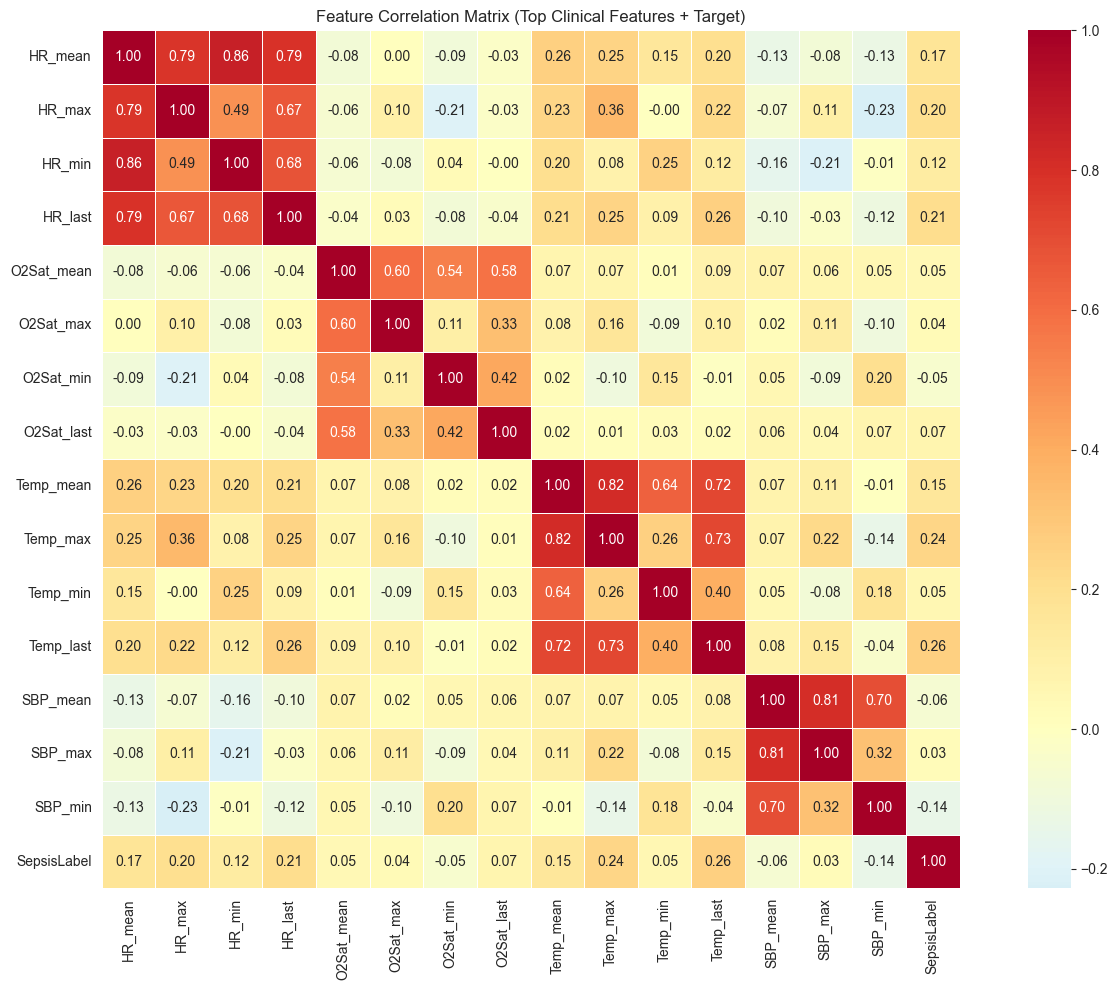


 Top 10 Features by |Correlation| with SepsisLabel:
              |Corr|
Temp_last   0.258217
Temp_max    0.237194
HR_last     0.212131
HR_max      0.203681
HR_mean     0.171529
Temp_mean   0.152189
SBP_min     0.141679
HR_min      0.120170
O2Sat_last  0.066709
SBP_mean    0.062888


In [23]:
#  6. Correlation Analysis

# Correlation matrix for top clinical features
top_clinical = [c for c in clinical_cols if any(v in c for v in ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp', 'WBC', 'Lactate'])][:15]

plt.figure(figsize=(14, 10))
corr_matrix = df[top_clinical + ['SepsisLabel']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Top Clinical Features + Target)')
plt.tight_layout()
plt.show()

# Highlight strongest correlations with target
target_corr = corr_matrix['SepsisLabel'].drop('SepsisLabel').abs().sort_values(ascending=False)
print(f"\n Top 10 Features by |Correlation| with SepsisLabel:")
print(target_corr.head(10).to_frame(name='|Corr|'))


<Figure size 1200x1000 with 0 Axes>

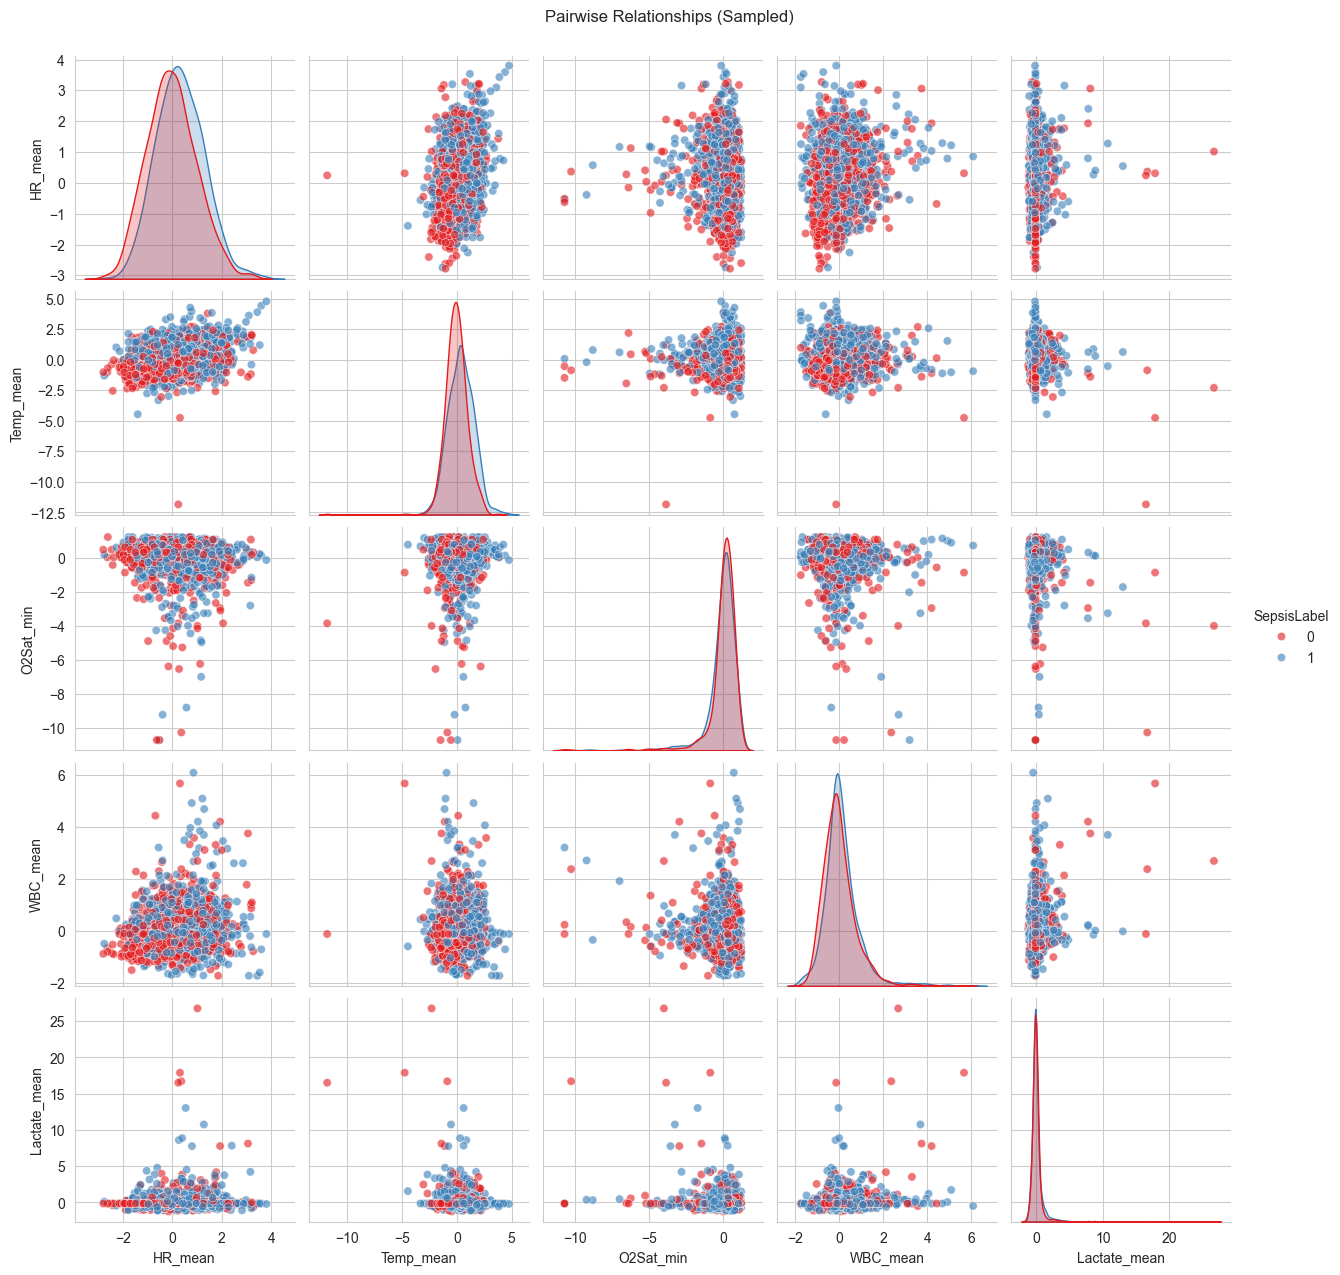

In [ ]:
#  Multivariate Visualization

# Pairplot for key features (sampled for performance)
key_features = ['HR_mean', 'Temp_mean', 'O2Sat_min', 'WBC_mean', 'Lactate_mean', 'SepsisLabel']
available_keys = [c for c in key_features if c in df.columns]

if len(available_keys) >= 4:
    # Sample data for pairplot (avoid memory issues)
    sample_df = df[available_keys].sample(min(2000, len(df)), random_state=42)
    
    plt.figure(figsize=(12, 10))
    sns.pairplot(sample_df, hue='SepsisLabel', palette='Set1', plot_kws={'alpha': 0.6})
    plt.suptitle('Pairwise Relationships (Sampled)', y=1.02)
    plt.show()


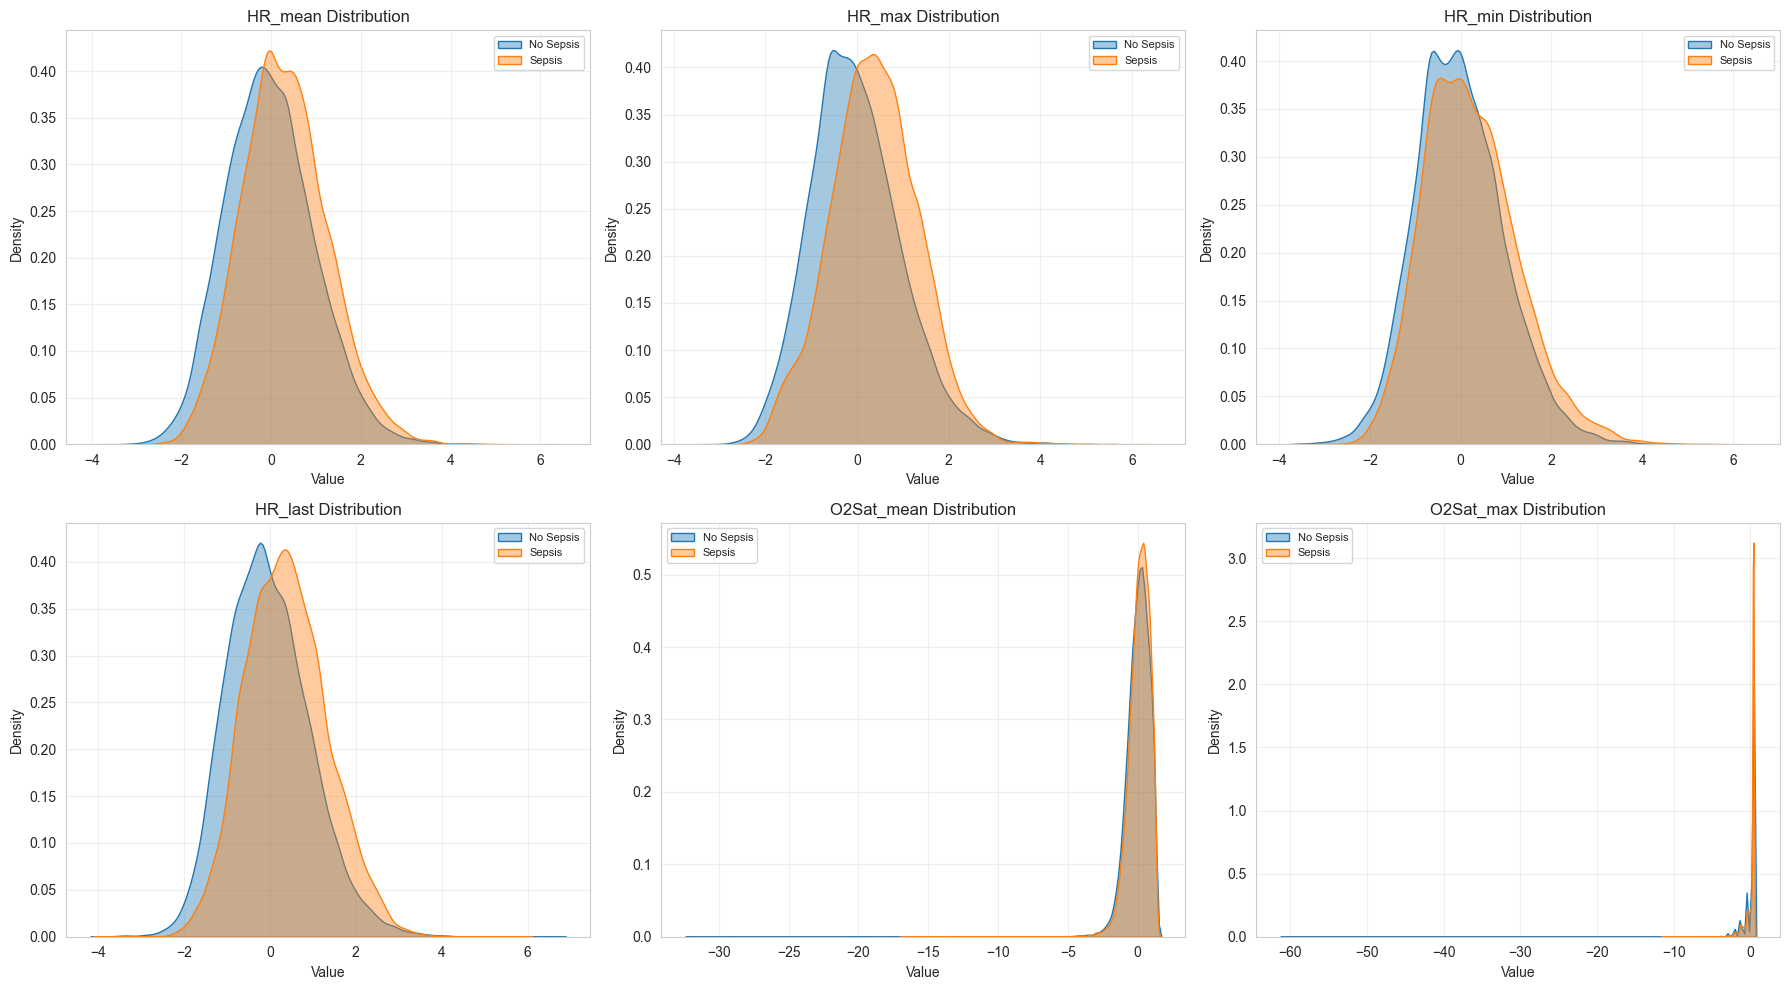

In [26]:
#  Univariate Analysis: Clinical Features

# Sample key vital sign features for visualization
vital_features = [c for c in clinical_cols if any(v in c for v in ['HR', 'O2Sat', 'Temp', 'SBP', 'Resp'])][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feat in enumerate(vital_features):
    if idx >= len(axes):
        break
    # Split by target for comparison
    sepsis_vals = df[df['SepsisLabel'] == 1][feat].dropna()
    non_sepsis_vals = df[df['SepsisLabel'] == 0][feat].dropna()
    
    # KDE plot
    sns.kdeplot(data=non_sepsis_vals, label='No Sepsis', ax=axes[idx], fill=True, alpha=0.4)
    sns.kdeplot(data=sepsis_vals, label='Sepsis', ax=axes[idx], fill=True, alpha=0.4)
    axes[idx].set_title(f'{feat} Distribution')
    axes[idx].set_xlabel('Value')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

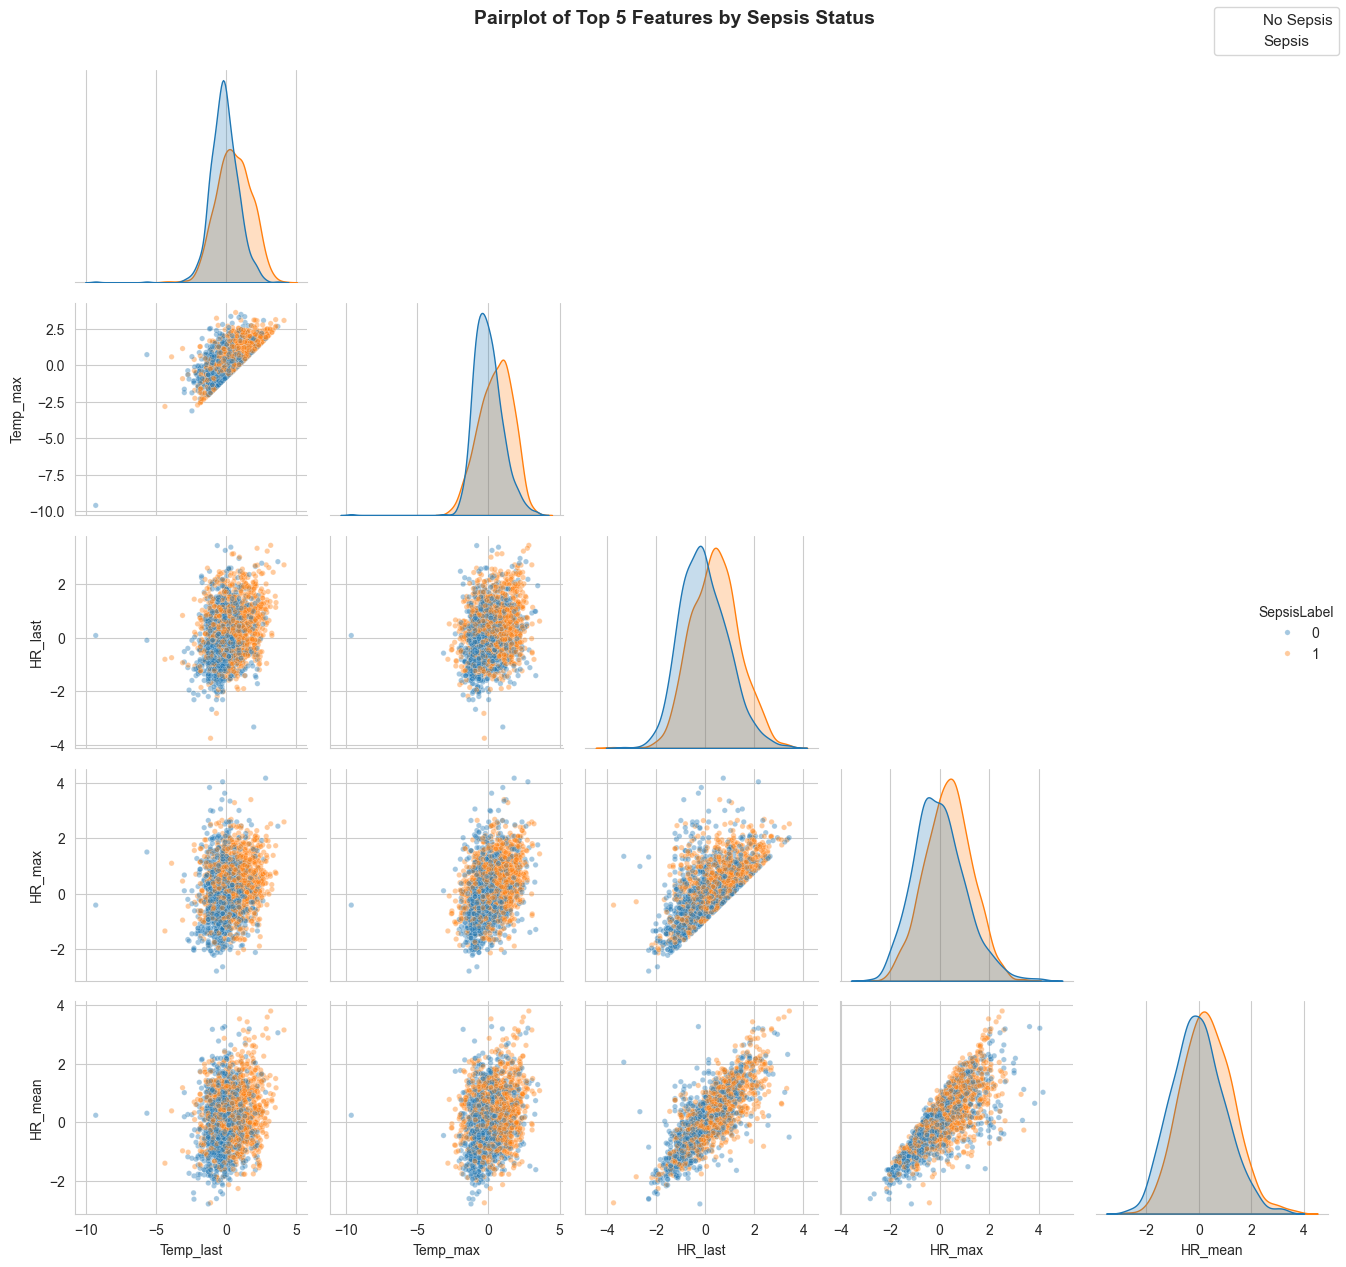

In [29]:
# Pairplot (Top 5 Features) 
# Using top correlated features + target
# Pairplots reveal inter-feature relationships and class separability across multiple dimensions simultaneously.

from termcolor import COLORS


top5 = target_corr.head(5).index.tolist()
plot_df = df[top5 + ['SepsisLabel']].sample(min(2000, len(df)), random_state=42)

g = sns.pairplot(
    plot_df,
    hue='SepsisLabel',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    corner=True
)
g.fig.suptitle('Pairplot of Top 5 Features by Sepsis Status', y=1.01,
               fontsize=14, fontweight='bold')
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
                markersize=10, label='No Sepsis'),
    plt.Line2D([0], [0], marker='o', color='w',
                markersize=10, label='Sepsis')
]
g.fig.legend(handles=handles, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import mannwhitneyu

def perform_statistical_tests(df, features):
    results = []
    for col in features:
        sepsis = df[df['SepsisLabel'] == 1][col]
        no_sepsis = df[df['SepsisLabel'] == 0][col]
        stat, p = mannwhitneyu(sepsis, no_sepsis)
        results.append({'Feature': col, 'p-value': p, 'Significant': p < 0.05})
    
    return pd.DataFrame(results).sort_values(by='p-value')

# Test core vital signs
vitals = ['HR_mean', 'Temp_max', 'Resp_mean', 'MAP_min', 'O2Sat_min']
stat_df = perform_statistical_tests(df, vitals)
print(stat_df)

     Feature       p-value  Significant
0    HR_mean  0.000000e+00         True
1   Temp_max  0.000000e+00         True
2  Resp_mean  0.000000e+00         True
3    MAP_min  0.000000e+00         True
4  O2Sat_min  1.034468e-95         True


In [32]:
from scipy.stats import chi2_contingency

def test_categorical_relationship(df, cat_column):
    # Create a contingency table
    contingency_table = pd.crosstab(df[cat_column], df['SepsisLabel'])
    
    # Run the test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"--- Chi-Square Test: {cat_column} vs SepsisLabel ---")
    print(f"Chi2 Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4e}")
    print("Significant" if p < 0.05 else "Not Significant")
    print("\n")

# Apply to categorical columns
categorical_cols = ['Gender_mean', 'Unit1_mean', 'Unit2_mean'] # Based on your aggregated names
for col in categorical_cols:
    test_categorical_relationship(df, col)

--- Chi-Square Test: Gender_mean vs SepsisLabel ---
Chi2 Statistic: 8710.5060
P-value: 4.1802e-30
Significant


--- Chi-Square Test: Unit1_mean vs SepsisLabel ---
Chi2 Statistic: 2611.0313
P-value: 4.7525e-02
Significant


--- Chi-Square Test: Unit2_mean vs SepsisLabel ---
Chi2 Statistic: 2611.0313
P-value: 4.7525e-02
Significant




In [33]:
from scipy.stats import f_oneway

def run_anova(df, cont_column):
    group_0 = df[df['SepsisLabel'] == 0][cont_column]
    group_1 = df[df['SepsisLabel'] == 1][cont_column]
    
    f_stat, p_val = f_oneway(group_0, group_1)
    
    return f_stat, p_val

# Testing multiple vitals
vitals = ['HR_mean', 'Temp_max', 'MAP_min', 'Resp_mean']
anova_results = []

for v in vitals:
    f, p = run_anova(df, v)
    anova_results.append({'Feature': v, 'F-Statistic': f, 'p-value': p})

anova_df = pd.DataFrame(anova_results)
print(anova_df.sort_values(by='F-Statistic', ascending=False))

     Feature  F-Statistic        p-value
1   Temp_max  3567.468823   0.000000e+00
0    HR_mean  1814.064812   0.000000e+00
2    MAP_min  1515.673442   0.000000e+00
3  Resp_mean  1350.933215  1.786188e-292


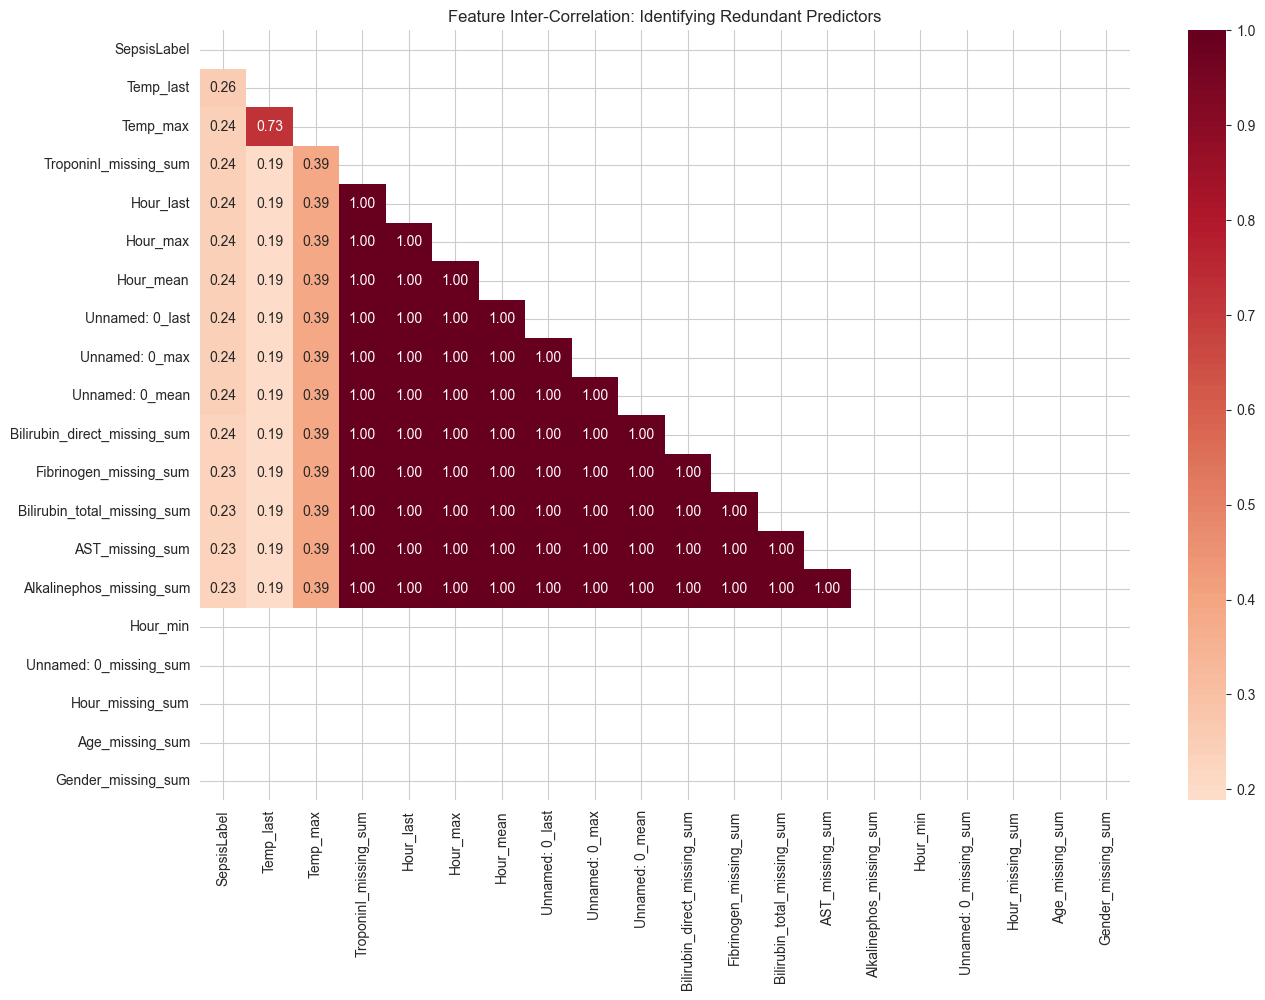

In [35]:
# 1. Multicollinearity Check
plt.figure(figsize=(15, 10))

# We select the top 20 features most correlated with the target to keep the map readable
top_corr_features = df.corr()['SepsisLabel'].sort_values(ascending=False).head(15).index.tolist()
top_corr_features += df.corr()['SepsisLabel'].sort_values(ascending=False).tail(5).index.tolist()

mask = np.triu(np.ones_like(df[top_corr_features].corr(), dtype=bool))
sns.heatmap(df[top_corr_features].corr(), mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f')

plt.title('Feature Inter-Correlation: Identifying Redundant Predictors')
plt.show()

<Figure size 1000x800 with 0 Axes>

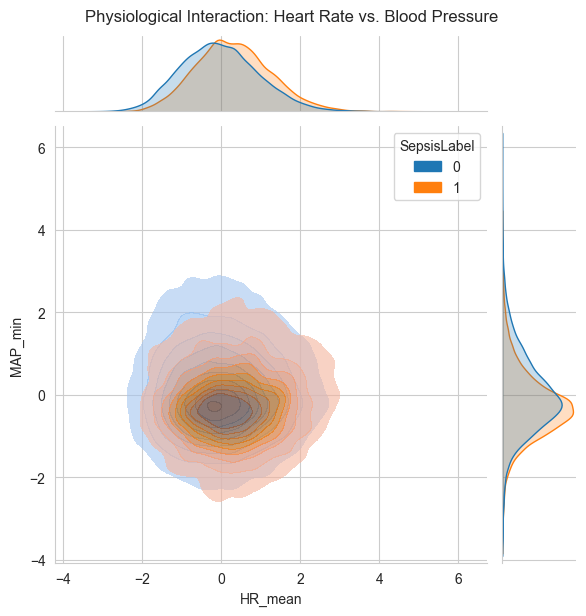

In [36]:
# 2. Clinical Interaction Plot
# Comparing Heart Rate and MAP (Mean Arterial Pressure)
plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x='HR_mean', y='MAP_min', hue='SepsisLabel', kind='kde', fill=True, alpha=0.6)
plt.suptitle('Physiological Interaction: Heart Rate vs. Blood Pressure', y=1.02)
plt.show()